In [1]:
from qiskit_trotter_circuit import *

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.transpiler.passes.synthesis.high_level_synthesis import HLSConfig
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp, Operator
from qiskit import transpile
import numpy as np
import matplotlib.pyplot as plt

# Test Trotter gate counts

In [10]:
D = 1
dt = 0.123414124124
n_steps=1

lattice_sizes = np.linspace(2**6, 2**12, 50)

b_ls = []
b_rzz = []
b_qs = []

n_ls = [[] for _ in range(5)]
n_rzz = [[] for _ in range(5)]
n_qs = [[] for _ in range(5)]

'''
n1_ls = []
n1_rzz = []
n1_qs = []

n2_ls = []
n2_rzz = []
n2_qs = []

n3_ls = []
n3_rzz = []
n3_qs = []

n4_ls = []
n4_rzz = []
n4_qs = []
'''

for ind in range(len(lattice_sizes)):
    # binary
    n = int(np.log2(lattice_sizes[ind]))
    if 2**n not in b_ls:
        b_ls.append(2**n)
        b_qs.append(n)

        qc = binary_gray_trotter_circuit(D, n, 0, dt, n_steps, with_ancilla=False)
        qc_t = transpile(qc, basis_gates=['rzz', 'u'], optimization_level=3)
        b_rzz.append(qc_t.count_ops()["rzz"])

    '''
    # n = 1
    n = 1
    q = int(round(lattice_sizes[ind]/2) * 2)
    n1_ls.append(q**n)

    qc = one_hot_gray_trotter_circuit(D, n, q, 0, dt, n_steps)
    qc_t = transpile(qc, basis_gates=['rzz', 'u'], optimization_level=3)
    n1_rzz.append(qc_t.count_ops()["rzz"])
    '''

    # n = 2
    for n in [2, 3, 4]:
        q = int(round(lattice_sizes[ind]**(1/n)/2) * 2)
        if q**n not in n_ls[n]:
            n_ls[n].append(q**(D*n))
            n_qs[n].append(D*n*q)

            qc = one_hot_gray_trotter_circuit(D, n, q, 0, dt, n_steps)
            qc_t = transpile(qc, basis_gates=['rzz', 'u'], optimization_level=3)
            n_rzz[n].append(qc_t.count_ops()["rzz"])

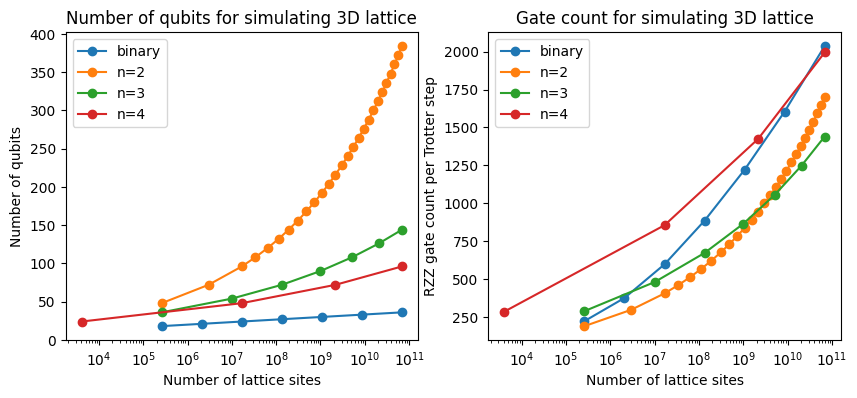

In [31]:
D = 3

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

axes[0].plot(np.array(b_ls)**D, D*np.array(b_qs), label="binary", marker='o')
#plt.plot(D*np.array(n1_ls), n1_rzz, label="n=1")
for n in [2, 3, 4]:
    if len(n_ls[n]) > 0:
        axes[0].plot(np.array(n_ls[n])**D, D*np.array(n_qs[n]), label=f"n={n}", marker='o')
#plt.plot(np.array(n3_ls)**D, D*np.array(n3_rzz), label="n=3")
#plt.plot(np.array(n4_ls)**D, D*np.array(n4_rzz), label="n=4")

D = 3
axes[1].plot(np.array(b_ls)**D, D*np.array(b_rzz), label="binary", marker='o')
#plt.plot(D*np.array(n1_ls), n1_rzz, label="n=1")
for n in [2, 3, 4]:
    if len(n_ls[n]) > 0:
        axes[1].plot(np.array(n_ls[n])**D, D*np.array(n_rzz[n]), label=f"n={n}", marker='o')
#plt.plot(np.array(n3_ls)**D, D*np.array(n3_rzz), label="n=3")
#plt.plot(np.array(n4_ls)**D, D*np.array(n4_rzz), label="n=4")

axes[0].set_title("Number of qubits for simulating 3D lattice")
axes[0].set_xlabel("Number of lattice sites")
axes[0].set_ylabel("Number of qubits")
axes[0].set_xscale("log")
axes[0].legend()

axes[1].set_title("Gate count for simulating 3D lattice")
axes[1].set_xlabel("Number of lattice sites")
axes[1].set_ylabel("RZZ gate count per Trotter step")
axes[1].set_xscale("log")
axes[1].legend()

plt.show()

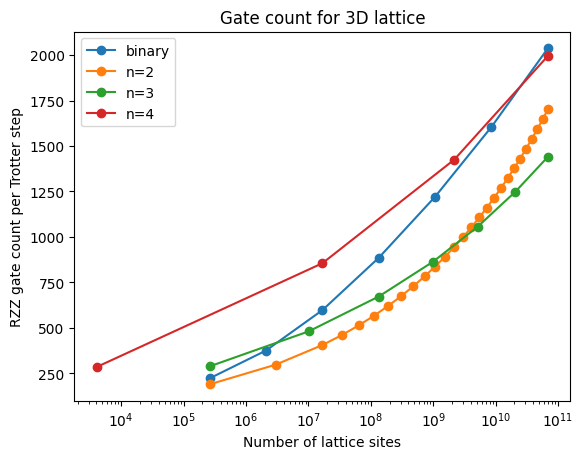

# Random tests

In [87]:
n = 3
theta = 0.12345

#controls = QuantumRegister(n-1, 'control')
#target = QuantumRegister(1, 'target')
#ancillas = QuantumRegister(n-2, 'ancilla') # N-2 ancillas for 5 controls
qc = QuantumCircuit(2*n)

# Use 'v-chain' for linear gate growth instead of exponential
# 1. First MCX (v-chain mode)
#qc.mcrx(theta, list(range(n-1)), n-1)

#'''
mode = "v-chain"
qc.mcx(list(range(n-1)), n-1, ancilla_qubits=list(range(n, 2*n-2)), mode=mode)
# 2. Single qubit rotation on target
qc.rx(-theta/2, n-1)
# 3. Second MCX (v-chain mode)
qc.mcx(list(range(n-1)), n-1, ancilla_qubits=list(range(n, 2*n-2)), mode=mode)
# 4. Final rotation on target
qc.rx(theta/2, n-1)
#'''


# When you transpile, Qiskit will respect this decomposition
qc_t = transpile(qc, basis_gates=['cx', 'u'], optimization_level=3)
qc_t.draw()

C:\Users\Jielun\AppData\Local\Temp\ipykernel_174796\1992407478.py:15: DeprecationWarning: ``qiskit.circuit.quantumcircuit.QuantumCircuit.mcx()``'s argument ``mode`` is deprecated as of Qiskit 2.1. It will be removed no earlier than 3 months after the release date. Instead, add a generic MCXGate to the circuit and specify the synthesis method via the ``hls_config`` in the transpilation. Alternatively, specific decompositions are available at https://qisk.it/mcx.
  qc.mcx(list(range(n-1)), n-1, ancilla_qubits=list(range(n, 2*n-2)), mode=mode)
C:\Users\Jielun\AppData\Local\Temp\ipykernel_174796\1992407478.py:19: DeprecationWarning: ``qiskit.circuit.quantumcircuit.QuantumCircuit.mcx()``'s argument ``mode`` is deprecated as of Qiskit 2.1. It will be removed no earlier than 3 months after the release date. Instead, add a generic MCXGate to the circuit and specify the synthesis method via the ``hls_config`` in the transpilation. Alternatively, specific decompositions are available at https://

»
q_0: ────────────────────────────────────■────────────────────────────────────»
                                         │                      ┌────────────┐»
q_1: ────────────────■───────────────────┼──────────────────■───┤ U(0,0,π/4) ├»
     ┌────────────┐┌─┴─┐┌─────────────┐┌─┴─┐┌────────────┐┌─┴─┐┌┴────────────┤»
q_2: ┤ U(π/2,0,π) ├┤ X ├┤ U(0,0,-π/4) ├┤ X ├┤ U(0,0,π/4) ├┤ X ├┤ U(0,0,-π/4) ├»
     └────────────┘└───┘└─────────────┘└───┘└────────────┘└───┘└─────────────┘»
q_3: ─────────────────────────────────────────────────────────────────────────»
                                                                              »
q_4: ─────────────────────────────────────────────────────────────────────────»
                                                                              »
q_5: ─────────────────────────────────────────────────────────────────────────»
                                                                              »
«                                   ┌────────────┐                         »
«q_0: ──■─────────────■─────────────┤ U(0,0,π/4) ├──■──────────────────────»
«       │           ┌─┴─┐          ┌┴────────────┤┌─┴─┐                    »
«q_1: ──┼───────────┤ X ├──────────┤ U(0,0,-π/4) ├┤ X ├──■─────────────────»
«     ┌─┴─┐┌────────┴───┴─────────┐└─────────────┘└───┘┌─┴─┐┌─────────────┐»
«q_2: ┤ X ├┤ U(0,1.5399,-0.81626) ├────────────────────┤ X ├┤ U(0,0,-π/4) ├»
«     └───┘└──────────────────────┘                    └───┘└─────────────┘»
«q_3: ─────────────────────────────────────────────────────────────────────»
«                                                                          »
«q_4: ─────────────────────────────────────────────────────────────────────»
«                                                                          »
«q_5: ─────────────────────────────────────────────────────────────────────»
«                                                                          »
«                                                                     »
«q_0: ──■──────────────────────────────────────■───────────■──────────»
«       │                      ┌────────────┐  │         ┌─┴─┐        »
«q_1: ──┼──────────────────■───┤ U(0,0,π/4) ├──┼─────────┤ X ├────────»
«     ┌─┴─┐┌────────────┐┌─┴─┐┌┴────────────┤┌─┴─┐┌──────┴───┴───────┐»
«q_2: ┤ X ├┤ U(0,0,π/4) ├┤ X ├┤ U(0,0,-π/4) ├┤ X ├┤ U(π/2,0,-2.2945) ├»
«     └───┘└────────────┘└───┘└─────────────┘└───┘└──────────────────┘»
«q_3: ────────────────────────────────────────────────────────────────»
«                                                                     »
«q_4: ────────────────────────────────────────────────────────────────»
«                                                                     »
«q_5: ────────────────────────────────────────────────────────────────»
«                                                                     »
«      ┌────────────┐     
«q_0: ─┤ U(0,0,π/4) ├──■──
«     ┌┴────────────┤┌─┴─┐
«q_1: ┤ U(0,0,-π/4) ├┤ X ├
«     └─────────────┘└───┘
«q_2: ────────────────────
«                         
«q_3: ────────────────────
«                         
«q_4: ────────────────────
«                         
«q_5: ────────────────────
«

In [25]:
np.sum([16*n-40 for n in range(30)])*3

np.int64(17280)

In [2]:
X = SparsePauliOp("X")
Y = SparsePauliOp("Y")
Z = SparsePauliOp("Z")
I = SparsePauliOp("I")
 
# build the evolution gate
operator = (X ^ X ^ X ^ X) + (X ^ X ^ Y ^ Y) + (X ^ Y ^ Y ^ X) + (Y ^ Y ^ X ^ X) + (X ^ Y ^ X ^ Y) + (Y ^ X ^ Y ^ X) + (Y ^ X ^ X ^ Y) + (Y ^ Y ^ Y ^ Y) 
evo = PauliEvolutionGate(operator, time=0.2)

qc = QuantumCircuit(4)
qc.append(evo, range(4))
qc = transpile(qc, basis_gates=["rzz", "u"], optimization_level=3)

qc.draw()

global phase: 1.7689
     ┌──────────────────┐                                       »
q_0: ┤ U(π/2,-2.705,-π) ├───────────────────────────────────────»
     └─┬──────────────┬─┘                                       »
q_1: ──┤ U(0,-π,-π/2) ├───────────────────────────────■─────────»
       ├──────────────┤             ┌───────────────┐ │ZZ(-π/2) »
q_2: ──┤ U(0,-π,-π/2) ├───■─────────┤ U(π/2,π/2,-π) ├─■─────────»
      ┌┴──────────────┤   │ZZ(-π/2) ├───────────────┤           »
q_3: ─┤ U(π/2,π/2,-π) ├───■─────────┤ U(π,-π/2,π/2) ├───────────»
      └───────────────┘             └───────────────┘           »
«                                 ┌────────────────────┐           »
«q_0: ──────────────────■─────────┤ U(π/2,-π/2,1.1342) ├───────────»
«     ┌───────────────┐ │ZZ(-0.4) └─┬────────────────┬─┘           »
«q_1: ┤ U(π/2,-π/2,0) ├─■───────────┤ U(π/2,-π/2,-π) ├───■─────────»
«     ├───────────────┤             └────────────────┘   │ZZ(-π/2) »
«q_2: ┤ U(π,-π/2,π/2) ├──────────────────────────────────■─────────»
«     └───────────────┘                                            »
«q_3: ─────────────────────────────────────────────────────────────»
«                                                                  »
«                                         ┌───────────────┐             »
«q_0: ─────────────────────────■──────────┤ U(π/2,-π,π/2) ├─────────────»
«     ┌──────────────────────┐ │ZZ(-0.4) ┌┴───────────────┴─┐           »
«q_1: ┤ U(π,-0.26908,1.3017) ├─■─────────┤ U(π/2,-π/2,-π/2) ├─■─────────»
«     └───┬─────────────┬────┘           └──────────────────┘ │ZZ(-π/2) »
«q_2: ────┤ U(π,-π,π/2) ├─────────────────────────────────────■─────────»
«         └─────────────┘                                               »
«q_3: ──────────────────────────────────────────────────────────────────»
«                                                                       »
«                                                               »
«q_0: ──────────────────────────────────────────────────────────»
«       ┌──────────────┐                                        »
«q_1: ──┤ U(0,-π,-π/2) ├──────────────────────────────■─────────»
«     ┌─┴──────────────┴┐            ┌─────────────┐  │ZZ(-π/2) »
«q_2: ┤ U(π/2,π/2,-π/2) ├─■──────────┤ U(0,0,-π/2) ├──■─────────»
«     └─────────────────┘ │ZZ(-π/2) ┌┴─────────────┴┐           »
«q_3: ────────────────────■─────────┤ U(π/2,π/4,-π) ├───────────»
«                                   └───────────────┘           »
«                                                              »
«q_0: ──────────────────■──────────────────────────────────────»
«     ┌───────────────┐ │ZZ(-0.4) ┌────────────────┐           »
«q_1: ┤ U(π/2,π/2,-π) ├─■─────────┤ U(π/2,π/2,π/2) ├─■─────────»
«     └─┬────────────┬┘           └────────────────┘ │ZZ(-π/2) »
«q_2: ──┤ U(0,0,π/2) ├───────────────────────────────■─────────»
«       └────────────┘                                         »
«q_3: ─────────────────────────────────────────────────────────»
«                                                              »
«                                                                     »
«q_0: ────────────────────────────────────────────────────────────────»
«     ┌────────────────┐                                              »
«q_1: ┤ U(π/2,π/2,π/2) ├────────────────────────────────────■─────────»
«     ├────────────────┤              ┌────────────────┐    │ZZ(-π/2) »
«q_2: ┤ U(π/2,-π/4,-π) ├─■────────────┤ U(π/2,π/2,π/4) ├────■─────────»
«     └────────────────┘ │ZZ(-π/2) ┌──┴────────────────┴──┐           »
«q_3: ───────────────────■─────────┤ U(π,-3.0706,-2.2852) ├───────────»
«                                  └──────────────────────┘           »
«                                  ┌──────────────┐                            »
«q_0: ──────────────────■──────────┤ U(π/2,π/2,0) ├────────────────────────────»
«     ┌───────────────┐ │ZZ(-0.4) ┌┴──────────────┴┐           ┌──────────────┐»
«q_1: ┤ U(π/2,π/2,-π) ├─■───